In [2]:
%load_ext autoreload
%autoreload 2
import sys
import os
ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")

Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


# Cluster 

In [3]:
HumanCT_Z2_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/Human.Cluster.Log2Mean.Z1clip5.Z2.clip3.Dec30.csv", index_col=0)
HumanCT_Z2_HCT.columns = HumanCT_Z2_HCT.columns.astype(int)

In [4]:
GeneWeightDIR = "../dat/GeneWeights/"
Bias_Save_Dict = "../dat/Bias_Feb27_2025/"
if not os.path.exists(Bias_Save_Dict): # make dir if not exists
    os.makedirs(Bias_Save_Dict)


In [5]:
# Compare effect sizes between subtypes within a supercluster vs other neuron types
def compare_supercluster_effects(df, supercluster):
    # Get subtypes within the supercluster
    supercluster_types = df[df['Supercluster'] == supercluster].index
    other_neurons = df[df['Supercluster'] != supercluster].index
    
    # Extract effect sizes
    supercluster_effects = df.loc[supercluster_types, 'EFFECT'].values
    other_effects = df.loc[other_neurons, 'EFFECT'].values
    
    # Perform mann whitney u test
    t_stat, p_value_gt = mannwhitneyu(supercluster_effects, other_effects, alternative='greater')
    t_stat, p_value_2sided = mannwhitneyu(supercluster_effects, other_effects)
    print(f"Mann-Whitney U test results for {supercluster}:")
    print(f"T-statistic: {t_stat}")
    print(f"P-value (greater): {p_value_gt}")
    print(f"P-value (2-sided): {p_value_2sided}")
# Compare effects for each supercluster
def compare_all_superclusters(df):
    results = []
    for sc in df['Supercluster'].unique():
        # Get subtypes within the supercluster
        supercluster_types = df[df['Supercluster'] == sc].index
        other_neurons = df[df['Supercluster'] != sc].index
        
        # Extract effect sizes
        supercluster_effects = df.loc[supercluster_types, 'EFFECT'].values
        other_effects = df.loc[other_neurons, 'EFFECT'].values
        
        # Perform mann whitney u test
        avg_supercluster_effect = np.mean(supercluster_effects)
        t_stat, p_value_gt = mannwhitneyu(supercluster_effects, other_effects, alternative='greater')
        t_stat, p_value_2sided = mannwhitneyu(supercluster_effects, other_effects)
        
        results.append({
            'Supercluster': sc,
            'Avg_supercluster_effect': avg_supercluster_effect,
            'P_value_gt': p_value_gt,
            'P_value_2sided': p_value_2sided,

        })

    results_df = pd.DataFrame(results)
    # sort by p-value
    results_df = results_df.sort_values(by='Avg_supercluster_effect', ascending=False)
    # perform multiple comparison correction
    results_df['P_value_gt_adj'] = multipletests(results_df['P_value_gt'], method='fdr_bh')[1]
    return results_df

#### ASD Bias

In [93]:
#ASD_GW = pd.read_csv("../../ASD_Circuits/dat/Unionize_bias/Spark_Meta_EWS.GeneWeight.csv", header=None)
#ASD_GW = dict(zip(ASD_GW[0].values, ASD_GW[1].values))

In [94]:
# ASD_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT_clip5, ASD_GW, Method = 1)
# ASD_Z2_Bias = AnnotateCTDat(ASD_Z2_Bias, Anno)
# ASD_Z2_Bias.to_csv("{}/HCT.ASD61.Z2.HCT.csv".format(Bias_Save_Dict))

In [95]:
# SuperClusterBias_BoxPlot(ASD_Z2_Bias, "ASD HCT")

### HIQ & LIQ ASD

In [6]:

HIQ_GW = Fil2Dict("{}/HIQ.top61.nopLI.gw".format(GeneWeightDIR))
LIQ_GW = Fil2Dict("{}/LIQ.top61.nopLI.gw".format(GeneWeightDIR))
print(len(HIQ_GW), len(LIQ_GW))

42 49


In [7]:
HIQ_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, HIQ_GW, Method = 1)
HIQ_Z2_Bias = AnnotateCTDat(HIQ_Z2_Bias, Anno)
HIQ_Z2_Bias.to_csv("{}/HCT.ASD61.HIQ.Z2.HCT.csv".format(Bias_Save_Dict))

LIQ_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, LIQ_GW, Method = 1)
LIQ_Z2_Bias = AnnotateCTDat(LIQ_Z2_Bias, Anno)
LIQ_Z2_Bias.to_csv("{}/HCT.ASD61.LIQ.Z2.HCT.csv".format(Bias_Save_Dict))

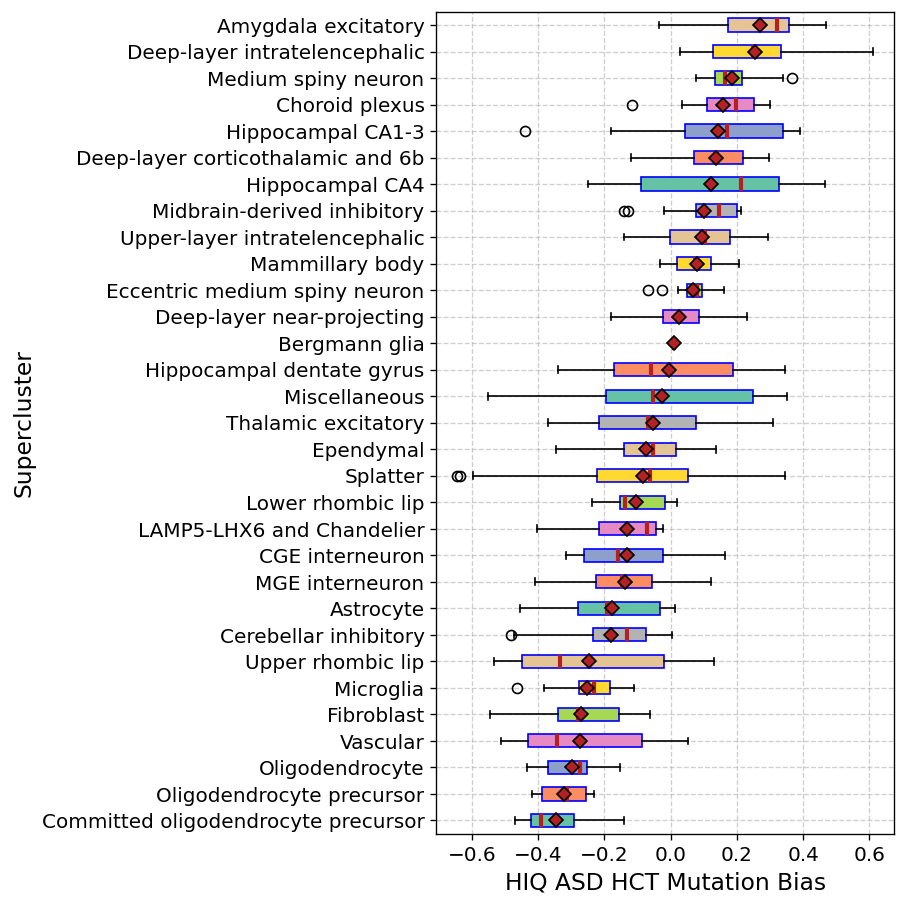

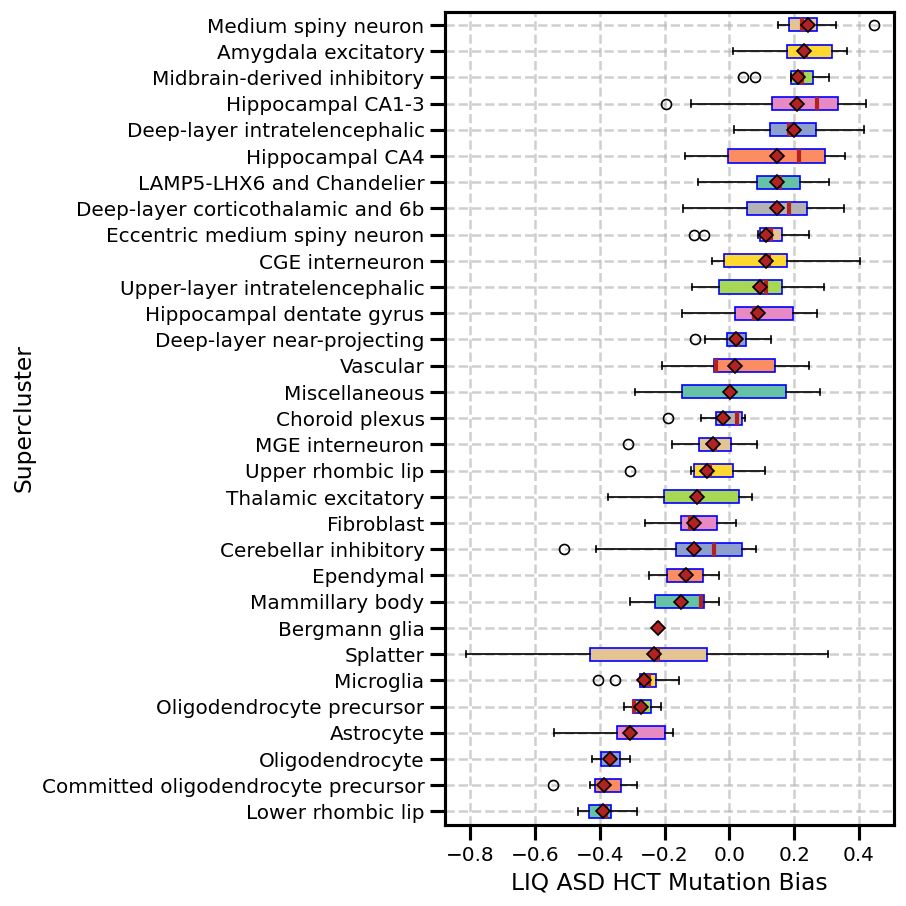

In [8]:
SuperClusterBias_BoxPlot(HIQ_Z2_Bias, "HIQ ASD HCT")
SuperClusterBias_BoxPlot(LIQ_Z2_Bias, "LIQ ASD HCT")

In [9]:
#HIQ_ASD_Supercluster_Bias = compare_all_superclusters(HIQ_Z2_Bias)
#LIQ_ASD_Supercluster_Bias = compare_all_superclusters(LIQ_Z2_Bias)


In [10]:
#HIQ_ASD_Supercluster_Bias.to_csv("{}/Supercluster_Bias_HIQ_ASD.csv".format(Bias_Save_Dict))
#LIQ_ASD_Supercluster_Bias.to_csv("{}/Supercluster_Bias_LIQ_ASD.csv".format(Bias_Save_Dict))


In [70]:
HIQ_ASD_Supercluster_Bias

,Supercluster,Avg_supercluster_effect,P_value_gt,P_value_2sided,P_value_gt_adj
1,Amygdala excitatory,0.271212,2.114596e-09,4.229192e-09,6.555247e-08
0,Deep-layer intratelencephalic,0.255111,6.653150e-07,1.330630e-06,1.031238e-05
4,Medium spiny neuron,0.184728,3.480466e-06,6.960931e-06,3.596481e-05
9,Choroid plexus,0.157167,7.808006e-03,1.561601e-02,3.727213e-02
3,Hippocampal CA1-3,0.143864,1.273577e-03,2.547154e-03,7.896178e-03
10,Deep-layer corticothalamic and 6b,0.136149,3.400118e-04,6.800236e-04,2.635091e-03
2,Hippocampal CA4,0.123296,4.275984e-02,8.551969e-02,1.205050e-01
13,Midbrain-derived inhibitory,0.101762,1.072680e-02,2.145361e-02,4.156637e-02
11,Upper-layer intratelencephalic,0.094199,8.416288e-03,1.683258e-02,3.727213e-02
14,Mammillary body,0.078404,3.801981e-02,7.603961e-02,1.178614e-01


In [71]:
LIQ_ASD_Supercluster_Bias

,Supercluster,Avg_supercluster_effect,P_value_gt,P_value_2sided,P_value_gt_adj
0,Medium spiny neuron,0.241318,2.682102e-08,5.364204e-08,4.157258e-07
4,Amygdala excitatory,0.230614,2.478908e-08,4.957816e-08,4.157258e-07
7,Midbrain-derived inhibitory,0.210301,3.117962e-05,6.235924e-05,1.933136e-04
1,Hippocampal CA1-3,0.208557,1.901430e-05,3.802860e-05,1.473608e-04
2,Deep-layer intratelencephalic,0.200846,1.056616e-05,2.113231e-05,1.091836e-04
5,Hippocampal CA4,0.147168,8.444047e-03,1.688809e-02,2.617655e-02
8,LAMP5-LHX6 and Chandelier,0.146528,2.302506e-03,4.605011e-03,8.922209e-03
6,Deep-layer corticothalamic and 6b,0.146202,3.423243e-04,6.846486e-04,1.768676e-03
14,Eccentric medium spiny neuron,0.113003,7.105743e-03,1.421149e-02,2.447534e-02
3,CGE interneuron,0.111737,1.668187e-03,3.336373e-03,7.387684e-03


#### LGD and Dmis same weights

In [11]:
HIQ_GW = Fil2Dict("{}/HIQ.top61.nopLI.LGD_Dmis_SameWeight.gw".format(GeneWeightDIR))
LIQ_GW = Fil2Dict("{}/LIQ.top61.nopLI.LGD_Dmis_SameWeight.gw".format(GeneWeightDIR))
print(len(HIQ_GW), len(LIQ_GW))

42 49


In [12]:
HIQ_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, HIQ_GW, Method = 1)
HIQ_Z2_Bias = AnnotateCTDat(HIQ_Z2_Bias, Anno)
HIQ_Z2_Bias.to_csv("{}/HCT.ASD61.HIQ.LGD_Dmis_SameWeight.Z2.HCT.csv".format(Bias_Save_Dict))

LIQ_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, LIQ_GW, Method = 1)
LIQ_Z2_Bias = AnnotateCTDat(LIQ_Z2_Bias, Anno)
LIQ_Z2_Bias.to_csv("{}/HCT.ASD61.LIQ.LGD_Dmis_SameWeight.Z2.HCT.csv".format(Bias_Save_Dict))

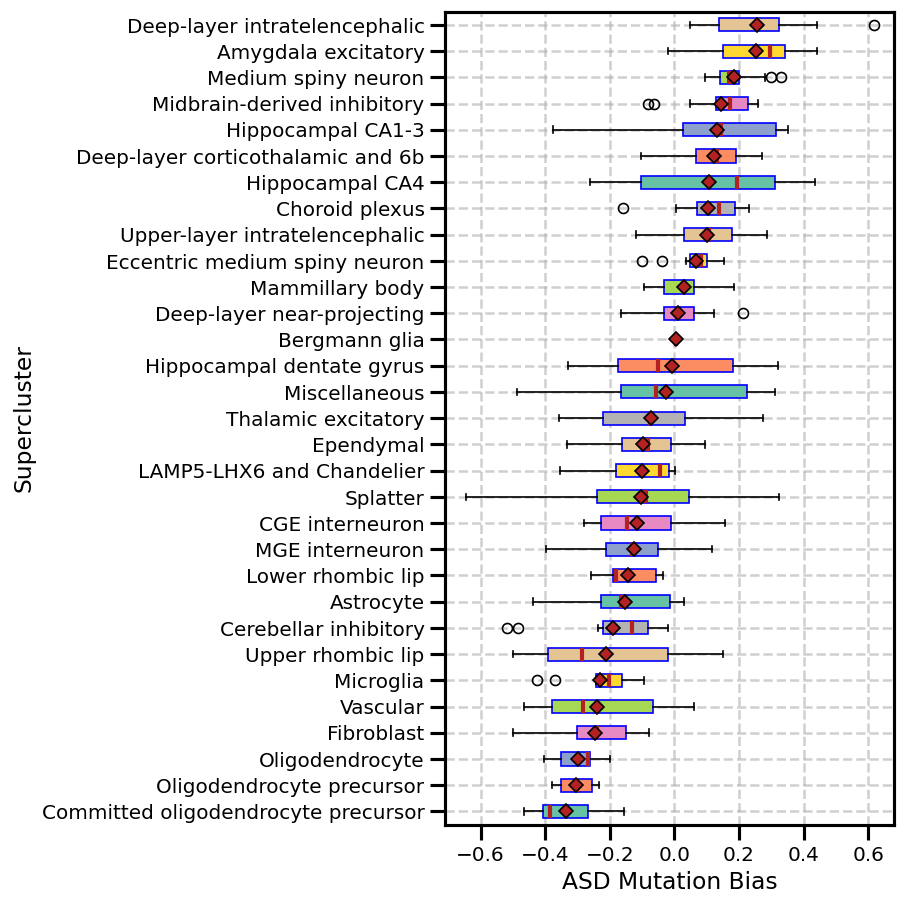

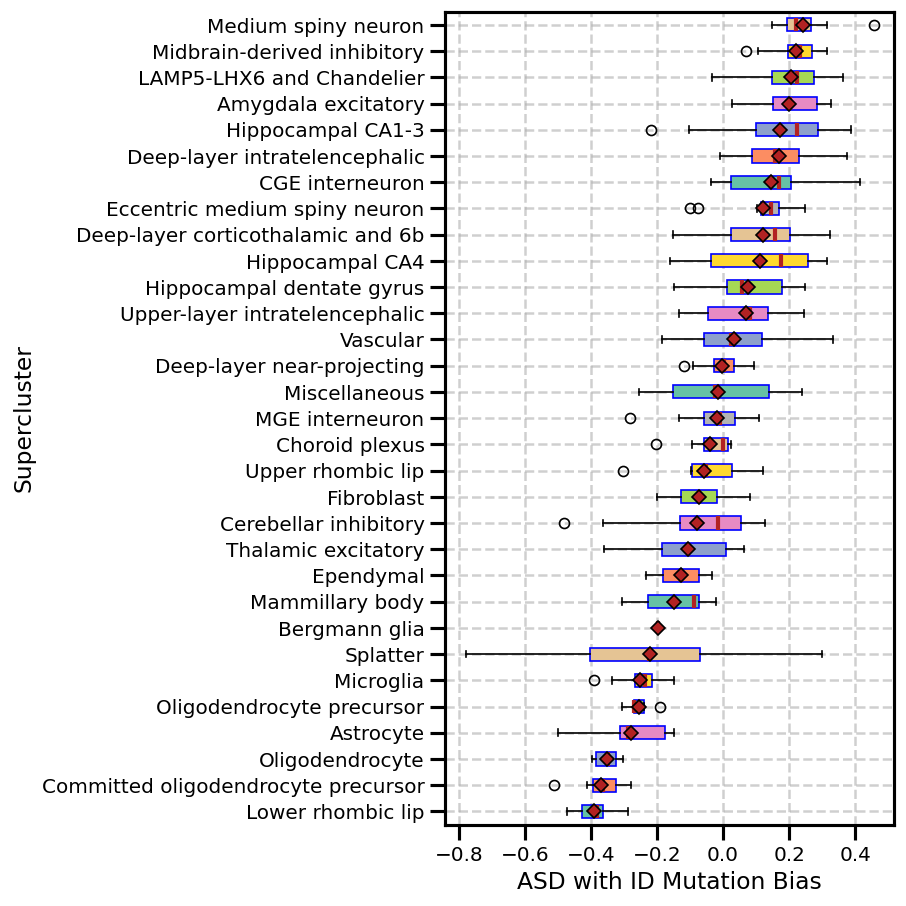

In [13]:
SuperClusterBias_BoxPlot(HIQ_Z2_Bias, "ASD")
SuperClusterBias_BoxPlot(LIQ_Z2_Bias, "ASD with ID")

In [14]:
HIQ_ASD_Supercluster_Bias = compare_all_superclusters(HIQ_Z2_Bias)
LIQ_ASD_Supercluster_Bias = compare_all_superclusters(LIQ_Z2_Bias)

In [15]:
HIQ_ASD_Supercluster_Bias.to_csv("{}/Supercluster_Bias_HIQ_ASD.csv".format(Bias_Save_Dict))
LIQ_ASD_Supercluster_Bias.to_csv("{}/Supercluster_Bias_LIQ_ASD.csv".format(Bias_Save_Dict))

In [16]:
HIQ_ASD_Supercluster_Bias

,Supercluster,Avg_supercluster_effect,P_value_gt,P_value_2sided,P_value_gt_adj
0,Deep-layer intratelencephalic,0.254771,1.709959e-07,3.419919e-07,2.650437e-06
1,Amygdala excitatory,0.253374,1.946240e-09,3.892480e-09,6.033344e-08
4,Medium spiny neuron,0.183391,1.155737e-06,2.311475e-06,1.194262e-05
11,Midbrain-derived inhibitory,0.145556,7.872626e-04,1.574525e-03,4.881028e-03
3,Hippocampal CA1-3,0.130237,1.477584e-03,2.955168e-03,7.634183e-03
10,Deep-layer corticothalamic and 6b,0.121006,4.690412e-04,9.380825e-04,3.635070e-03
2,Hippocampal CA4,0.107224,4.559074e-02,9.118148e-02,1.413313e-01
12,Choroid plexus,0.103251,3.317975e-02,6.635951e-02,1.142858e-01
8,Upper-layer intratelencephalic,0.100446,3.127158e-03,6.254316e-03,1.384884e-02
16,Eccentric medium spiny neuron,0.066317,2.412567e-02,4.825134e-02,9.348697e-02


In [17]:
LIQ_ASD_Supercluster_Bias

,Supercluster,Avg_supercluster_effect,P_value_gt,P_value_2sided,P_value_gt_adj
0,Medium spiny neuron,0.240889,1.132740e-08,2.265479e-08,3.511493e-07
9,Midbrain-derived inhibitory,0.220994,8.793056e-06,1.758611e-05,9.086158e-05
4,LAMP5-LHX6 and Chandelier,0.205468,5.160009e-05,1.032002e-04,3.999007e-04
6,Amygdala excitatory,0.200647,2.214376e-07,4.428753e-07,3.432283e-06
2,Hippocampal CA1-3,0.172138,9.612031e-05,1.922406e-04,4.256757e-04
3,Deep-layer intratelencephalic,0.168265,7.815867e-05,1.563173e-04,4.079895e-04
1,CGE interneuron,0.144860,7.896571e-05,1.579314e-04,4.079895e-04
11,Eccentric medium spiny neuron,0.121994,3.658231e-03,7.316462e-03,1.260057e-02
7,Deep-layer corticothalamic and 6b,0.119848,1.798558e-03,3.597117e-03,6.969414e-03
8,Hippocampal CA4,0.113237,2.502299e-02,5.004597e-02,7.757126e-02


## SCZ Bias

In [19]:
# SCZ_GW = Fil2Dict("{}/SCZ_MutCount_61.gw".format(GeneWeightDIR))
# SCZ_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, SCZ_GW, Method = 1)
# SCZ_Z2_Bias = AnnotateCTDat(SCZ_Z2_Bias, Anno)
# SCZ_Z2_Bias.to_csv("{}/HCT.SCZ61.Z2.HCT.csv".format(Bias_Save_Dict))
# SuperClusterBias_BoxPlot(SCZ_Z2_Bias, "SCZ HCT")
# SCZ_Supercluster_Bias = compare_all_superclusters(SCZ_Z2_Bias)


In [20]:
# SCZ_GW = Fil2Dict("{}/SCZ.top61.nopLI.OR.gw".format(GeneWeightDIR))
# SCZ_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, SCZ_GW, Method = 1)
# SCZ_Z2_Bias = AnnotateCTDat(SCZ_Z2_Bias, Anno)
# SCZ_Z2_Bias.to_csv("{}/HCT.SCZ61.OR.Z2.HCT.csv".format(Bias_Save_Dict))
# SuperClusterBias_BoxPlot(SCZ_Z2_Bias, "SCZ HCT")

In [108]:
SCZ_Supercluster_Bias = compare_all_superclusters(SCZ_Z2_Bias)
SCZ_Supercluster_Bias

,Supercluster,Avg_supercluster_effect,P_value_gt,P_value_2sided,P_value_gt_adj
5,Midbrain-derived inhibitory,0.206399,1.091904e-05,2.183808e-05,8.462256e-05
0,Amygdala excitatory,0.199239,6.693351e-09,1.338670e-08,2.074939e-07
3,Hippocampal CA1-3,0.185281,9.397499e-06,1.879500e-05,8.462256e-05
1,Eccentric medium spiny neuron,0.178160,5.792455e-06,1.158491e-05,8.462256e-05
16,Upper-layer intratelencephalic,0.094660,3.866941e-03,7.733882e-03,2.397503e-02
7,Hippocampal dentate gyrus,0.089919,7.440453e-02,1.488091e-01,2.883175e-01
12,Mammillary body,0.085483,2.931433e-02,5.862865e-02,1.514574e-01
4,Deep-layer intratelencephalic,0.084299,4.395097e-02,8.790194e-02,1.946400e-01
8,Hippocampal CA4,0.062154,1.618865e-01,3.237729e-01,4.182067e-01
13,LAMP5-LHX6 and Chandelier,0.051221,1.581000e-01,3.162000e-01,4.182067e-01


In [21]:
# SCZ_GW = Fil2Dict("{}/SCZ.top61.nopLI.MC.gw".format(GeneWeightDIR))
# SCZ_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, SCZ_GW, Method = 1)
# SCZ_Z2_Bias = AnnotateCTDat(SCZ_Z2_Bias, Anno)
# SCZ_Z2_Bias.to_csv("{}/HCT.SCZ61.MC.Z2.HCT.csv".format(Bias_Save_Dict))
# SuperClusterBias_BoxPlot(SCZ_Z2_Bias, "SCZ HCT")

In [110]:
SCZ_Supercluster_Bias = compare_all_superclusters(SCZ_Z2_Bias)
SCZ_Supercluster_Bias

,Supercluster,Avg_supercluster_effect,P_value_gt,P_value_2sided,P_value_gt_adj
6,Mammillary body,0.214142,0.000047,9.353493e-05,0.000725
9,Midbrain-derived inhibitory,0.195948,0.000159,3.185748e-04,0.001311
0,Deep-layer intratelencephalic,0.189631,0.000169,3.382629e-04,0.001311
1,Amygdala excitatory,0.183289,0.000032,6.445651e-05,0.000725
8,Eccentric medium spiny neuron,0.151575,0.003484,6.967693e-03,0.018000
11,Upper-layer intratelencephalic,0.146273,0.001503,3.005650e-03,0.009318
2,Hippocampal CA1-3,0.135059,0.007789,1.557702e-02,0.030180
7,Thalamic excitatory,0.134705,0.007114,1.422868e-02,0.030180
12,Deep-layer near-projecting,0.126574,0.018041,3.608297e-02,0.055929
5,MGE interneuron,0.112772,0.011260,2.251931e-02,0.038783


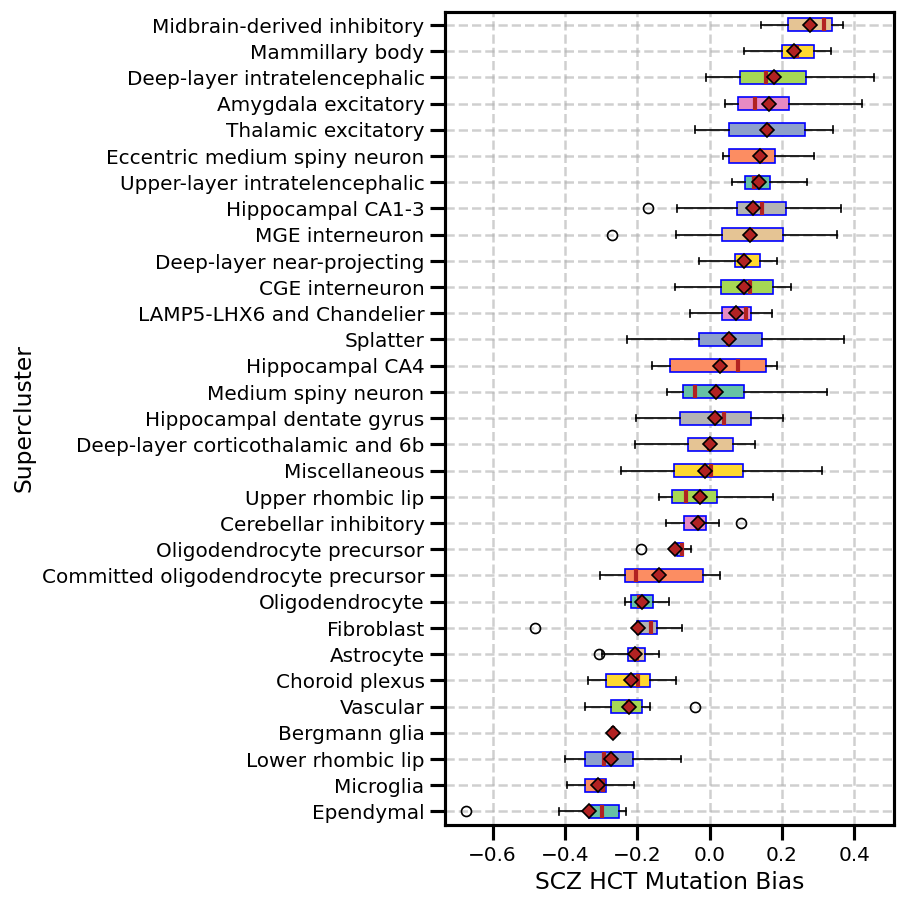

In [22]:
SCZ_GW = Fil2Dict("{}/SCZ.top61.nopLI.LGD_Dmis_SameWeight.gw".format(GeneWeightDIR))
SCZ_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, SCZ_GW, Method = 1)
SCZ_Z2_Bias = AnnotateCTDat(SCZ_Z2_Bias, Anno)
SCZ_Z2_Bias.to_csv("{}/HCT.SCZ61.MC.LGD_Dmis_SameWeight.Z2.HCT.csv".format(Bias_Save_Dict))
SuperClusterBias_BoxPlot(SCZ_Z2_Bias, "SCZ HCT")

In [23]:
SCZ_Supercluster_Bias = compare_all_superclusters(SCZ_Z2_Bias)
SCZ_Supercluster_Bias

,Supercluster,Avg_supercluster_effect,P_value_gt,P_value_2sided,P_value_gt_adj
3,Midbrain-derived inhibitory,0.277998,4.645311e-07,9.290622e-07,0.000014
7,Mammillary body,0.232670,1.803852e-05,3.607705e-05,0.000280
0,Deep-layer intratelencephalic,0.179069,5.734902e-04,1.146980e-03,0.004445
1,Amygdala excitatory,0.164717,2.696288e-04,5.392576e-04,0.002786
6,Thalamic excitatory,0.157706,1.315081e-03,2.630162e-03,0.008154
10,Eccentric medium spiny neuron,0.138849,7.227339e-03,1.445468e-02,0.028648
11,Upper-layer intratelencephalic,0.137358,2.234479e-03,4.468959e-03,0.011545
4,Hippocampal CA1-3,0.120839,1.614305e-02,3.228611e-02,0.055604
5,MGE interneuron,0.112211,7.392911e-03,1.478582e-02,0.028648
15,Deep-layer near-projecting,0.095609,7.415206e-02,1.483041e-01,0.208974


In [24]:
SCZ_Supercluster_Bias.to_csv("{}/Supercluster_Bias_SCZ.csv".format(Bias_Save_Dict))

### ASD SCZ correlation after remove common genes

In [28]:
# Get common keys between HIQ_GW and SCZ_GW
common_keys = set(HIQ_GW.keys()) & set(SCZ_GW.keys())

# Create new dicts excluding common keys
HIQ_GW_unique = {k:v for k,v in HIQ_GW.items() if k not in common_keys}
SCZ_GW_unique = {k:v for k,v in SCZ_GW.items() if k not in common_keys}
print(len(HIQ_GW), len(SCZ_GW))
print(len(HIQ_GW_unique), len(SCZ_GW_unique))

42 61
40 59


In [30]:
SCZ_Z2_Bias_unique = AvgCTZ_Weighted(HumanCT_Z2_HCT, SCZ_GW_unique, Method = 1)
SCZ_Z2_Bias_unique = AnnotateCTDat(SCZ_Z2_Bias_unique, Anno)
ASD_HIQ_Bias_unique = AvgCTZ_Weighted(HumanCT_Z2_HCT, HIQ_GW_unique, Method = 1)
ASD_HIQ_Bias_unique = AnnotateCTDat(ASD_HIQ_Bias_unique, Anno)
SCZ_Z2_Bias_unique.to_csv("{}/HCT.SCZ61.MC.LGD_Dmis_SameWeight.Z2.HCT.unique.csv".format(Bias_Save_Dict))
ASD_HIQ_Bias_unique.to_csv("{}/HCT.ASD_HIQ.MC.LGD_Dmis_SameWeight.Z2.HCT.unique.csv".format(Bias_Save_Dict))

## 22q.11 Bias

In [25]:
X22q_GW = Fil2Dict("../dat/GeneWeights/X22q.gw.csv")
X22q_GW_Mouse = Fil2Dict("{}/X22q.mousemodel.gw.csv".format(GeneWeightDIR))

In [26]:
X22q_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, X22q_GW, Method = 1)
#X22q_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT_clip5, X22q_GW, Method = 1)
X22q_Z2_Bias = AnnotateCTDat(X22q_Z2_Bias, Anno)
X22q_Z2_Bias.to_csv("{}/HCT.X22q.Z2.HCT.csv".format(Bias_Save_Dict))


In [27]:
X22q_Z2_Bias.head(2)

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation
400,0.570685,1,NEUR,Splatter,,CHOL VGLUT3,"Basal forebrain: 54.0%, Amygdala: 22.9%, Hypot...","Human SI: 18.9%, Human BNST: 13.9%, Human HTHp...",769.0,CHGA CHGB GNRH IGF NAMPT NPPC NUCB PENK SCG UB...
136,0.488321,2,NEUR,Deep-layer intratelencephalic,,VGLUT1 VGLUT2,"Amygdala: 54.6%, Cerebral cortex: 36.2%, Hypot...","Human CoA: 54.6%, Human AON: 28.3%, Human HTHs...",152.0,ADCYAP CBLN CCK CHGA CHGB CRH NAMPT NUCB PYY S...


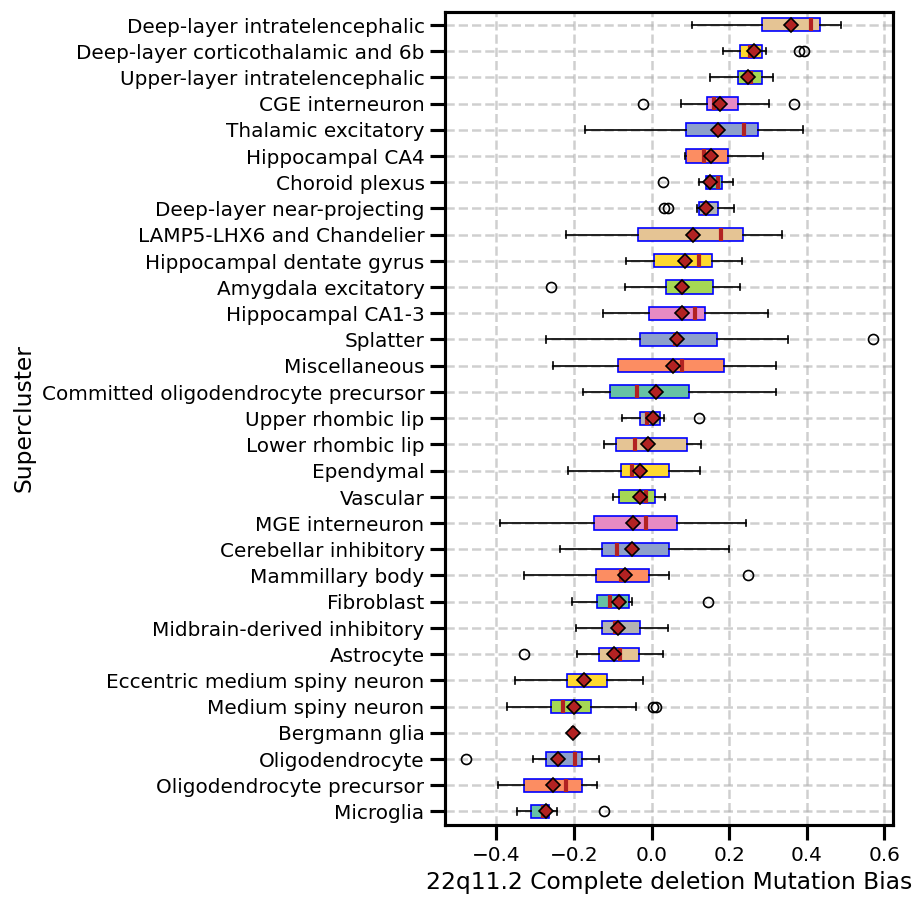

In [28]:
SuperClusterBias_BoxPlot(X22q_Z2_Bias, "22q11.2 Complete deletion")

In [33]:
X22q_Supercluster_Bias = compare_all_superclusters(X22q_Z2_Bias)

In [34]:
X22q_Z2_Mouse_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, X22q_GW_Mouse, Method = 1)
X22q_Z2_Mouse_Bias = AnnotateCTDat(X22q_Z2_Mouse_Bias, Anno)
X22q_Z2_Mouse_Bias.to_csv("{}/HCT.X22q.mousemodel.Z2.HCT.csv".format(Bias_Save_Dict))

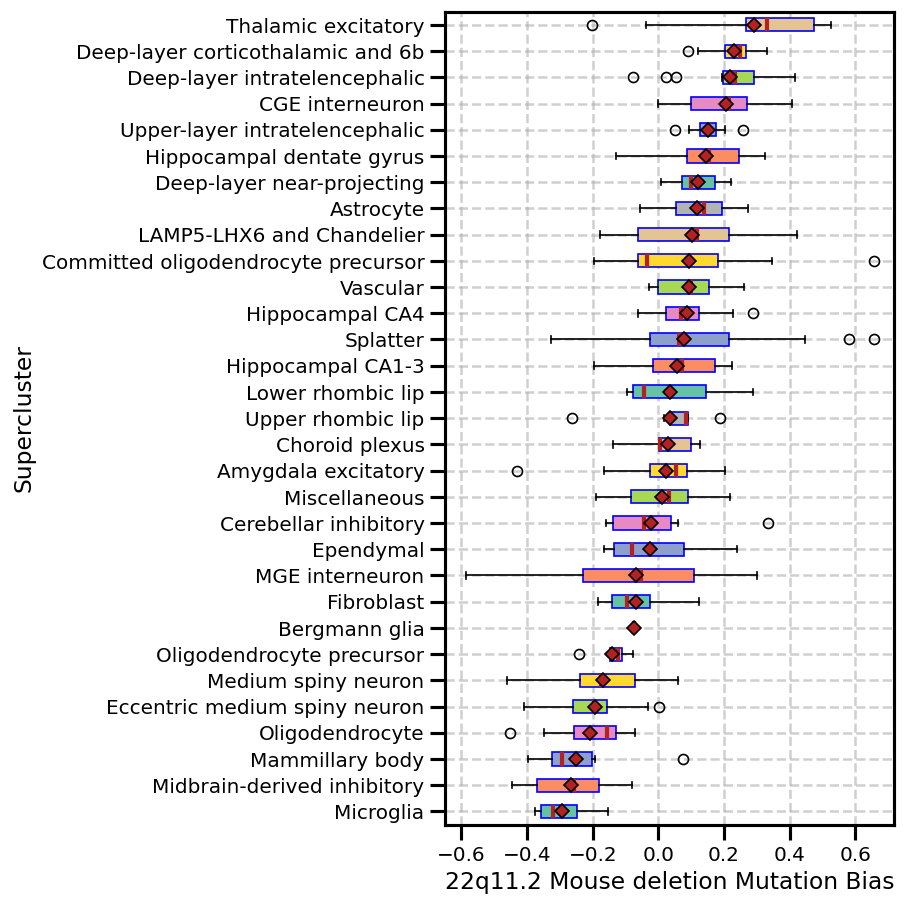

In [35]:
SuperClusterBias_BoxPlot(X22q_Z2_Mouse_Bias, "22q11.2 Mouse deletion")

In [36]:
X22q_smallDel_Supercluster_Bias = compare_all_superclusters(X22q_Z2_Mouse_Bias)

In [37]:
X22q_Supercluster_Bias.to_csv("{}/Supercluster_Bias_X22q.csv".format(Bias_Save_Dict))
X22q_smallDel_Supercluster_Bias.to_csv("{}/Supercluster_Bias_X22q_smallDel.csv".format(Bias_Save_Dict))

## DDD

In [39]:
DDD_top61_GW = Fil2Dict("{}/DDD.top61.gw.csv".format(GeneWeightDIR))
DDD_hc_Bias_top61 = AvgCTZ_Weighted(HumanCT_Z2_HCT, DDD_top61_GW, Method = 1)
DDD_hc_Bias_top61 = AnnotateCTDat(DDD_hc_Bias_top61, Anno)
DDD_hc_Bias_top61.to_csv("{}/HCT.DDDHC.Z2.HCT.top61.csv".format(Bias_Save_Dict))

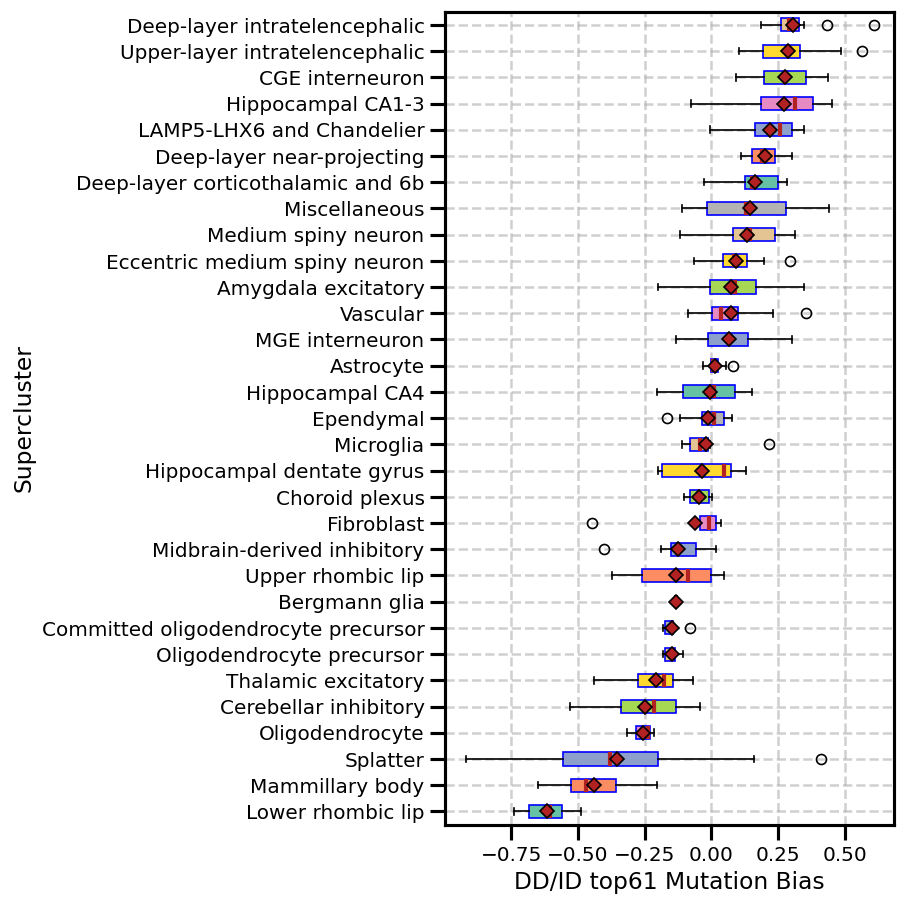

In [40]:
SuperClusterBias_BoxPlot(DDD_hc_Bias_top61, "DD/ID top61")

In [41]:
DDD_top61_Supercluster_Bias = compare_all_superclusters(DDD_hc_Bias_top61)
DDD_top61_Supercluster_Bias.to_csv("{}/Supercluster_Bias_DDD_top61.csv".format(Bias_Save_Dict))
DDD_top61_Supercluster_Bias

,Supercluster,Avg_supercluster_effect,P_value_gt,P_value_2sided,P_value_gt_adj
0,Deep-layer intratelencephalic,0.308087,2.410648e-08,4.821295e-08,3.736504e-07
1,Upper-layer intratelencephalic,0.289014,1.675791e-07,3.351582e-07,1.731651e-06
4,CGE interneuron,0.277367,2.425145e-09,4.850289e-09,7.517949e-08
2,Hippocampal CA1-3,0.273937,1.388771e-06,2.777541e-06,1.076297e-05
7,LAMP5-LHX6 and Chandelier,0.219600,1.689667e-04,3.379334e-04,1.023545e-03
10,Deep-layer near-projecting,0.201258,1.981055e-04,3.962110e-04,1.023545e-03
13,Deep-layer corticothalamic and 6b,0.163105,4.418353e-04,8.836706e-04,1.956699e-03
3,Miscellaneous,0.145759,9.144622e-04,1.828924e-03,3.543541e-03
9,Medium spiny neuron,0.135509,2.553841e-03,5.107682e-03,8.796564e-03
12,Eccentric medium spiny neuron,0.093706,3.774042e-02,7.548084e-02,1.122936e-01


In [43]:
DDD_hc_GW = Fil2Dict("{}/DDD.hc.gw.csv".format(GeneWeightDIR))
DDD_hc_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, DDD_hc_GW, Method = 1)
DDD_hc_Bias = AnnotateCTDat(DDD_hc_Bias, Anno)
DDD_hc_Bias.to_csv("{}/HCT.DDDHC.Z2.HCT.csv".format(Bias_Save_Dict))

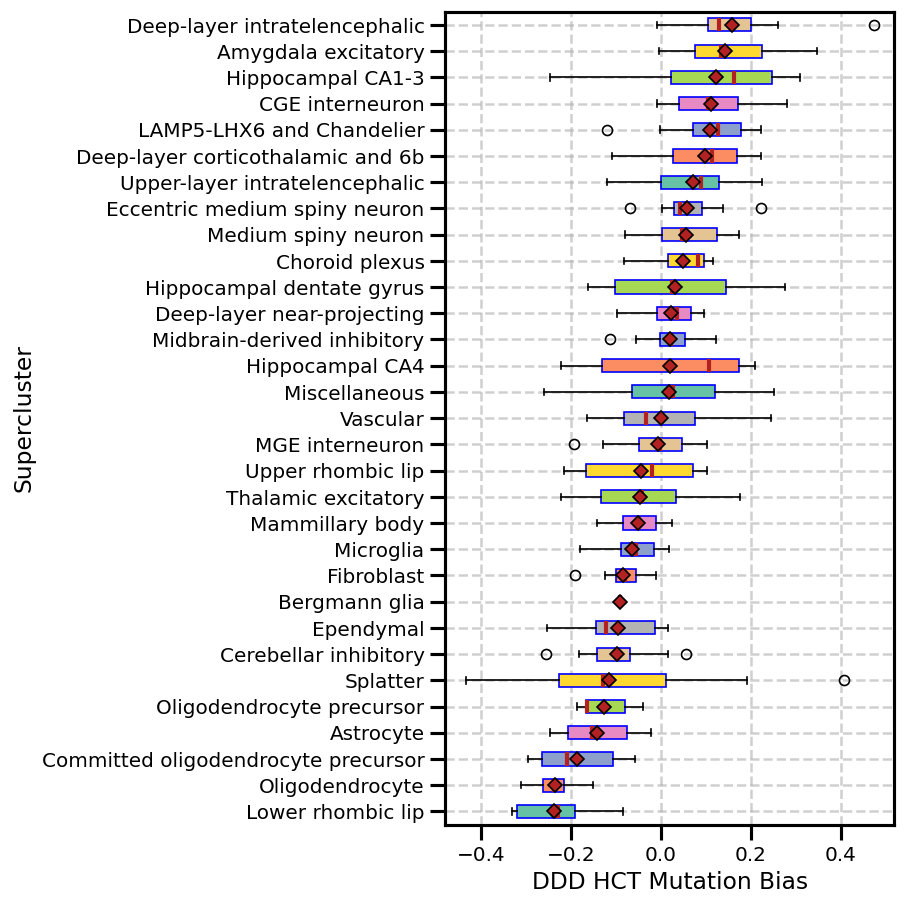

In [44]:
SuperClusterBias_BoxPlot(DDD_hc_Bias, "DDD HCT")

## VNR

In [42]:
topN = 61
VNR_Pos_GW = Fil2Dict("{}/UKBB_VNR_Pos_GW_{}.csv".format(GeneWeightDIR, topN))
VNR_Neg_GW = Fil2Dict("{}/UKBB_VNR_Neg_GW_{}.csv".format(GeneWeightDIR, topN))
VNR_Pos_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, VNR_Pos_GW, Method = 1)
VNR_Pos_Bias = AnnotateCTDat(VNR_Pos_Bias, Anno)
VNR_Neg_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, VNR_Neg_GW, Method = 1)
VNR_Neg_Bias = AnnotateCTDat(VNR_Neg_Bias, Anno)
VNR_Pos_Bias.to_csv("{}/CTBias.VNR.Pos.top61.csv".format(Bias_Save_Dict))
VNR_Neg_Bias.to_csv("{}/CTBias.VNR.Neg.top61.csv".format(Bias_Save_Dict))

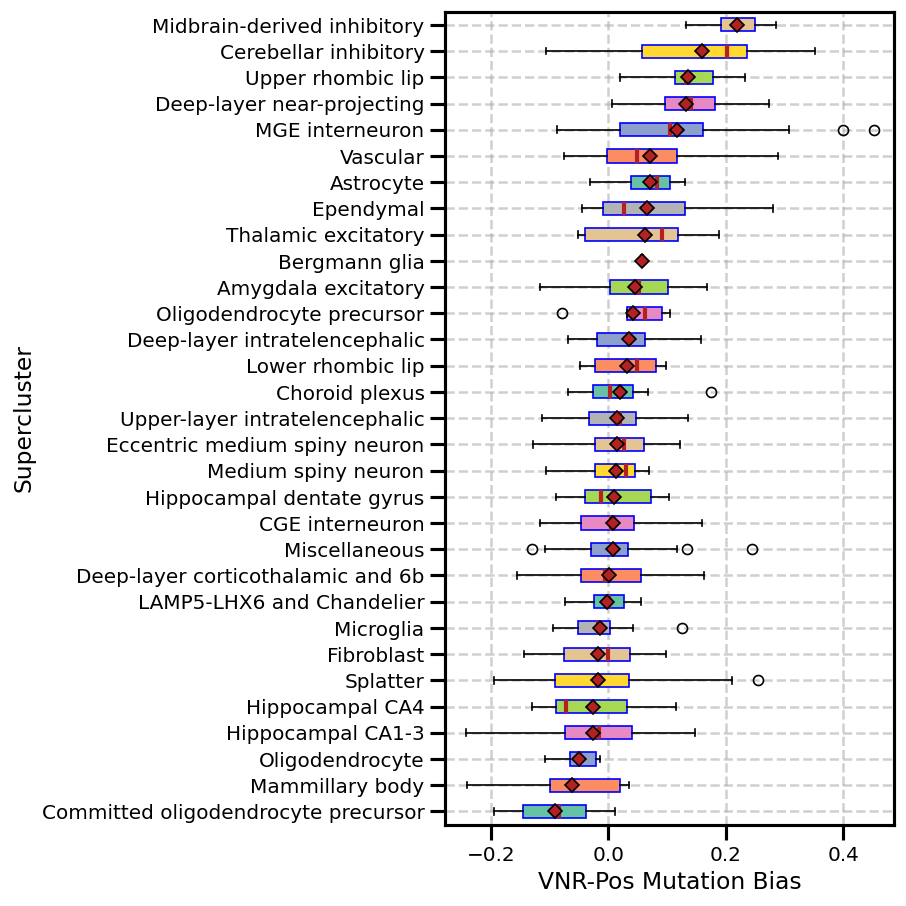

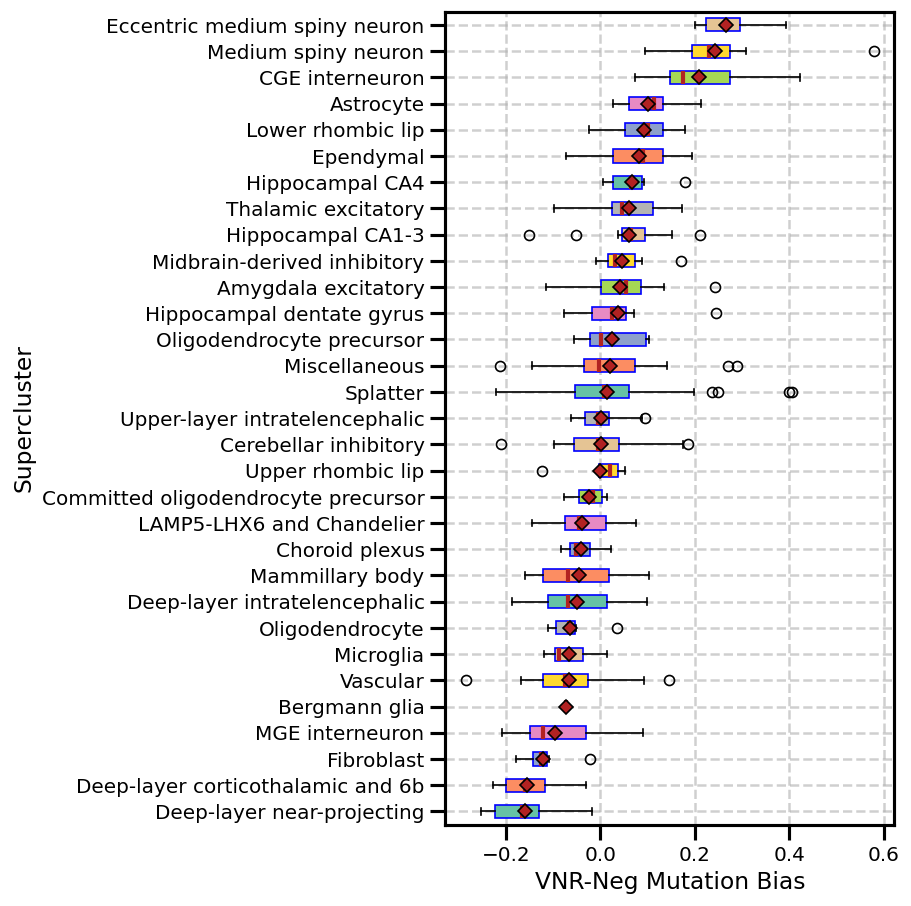

In [43]:
SuperClusterBias_BoxPlot(VNR_Pos_Bias, "VNR-Pos")
SuperClusterBias_BoxPlot(VNR_Neg_Bias, "VNR-Neg")

In [44]:
VNR_Neg_Supercluster_Bias = compare_all_superclusters(VNR_Neg_Bias)
VNR_Neg_Supercluster_Bias.to_csv("{}/Supercluster_Bias_VNR_Neg.csv".format(Bias_Save_Dict))
VNR_Neg_Supercluster_Bias

,Supercluster,Avg_supercluster_effect,P_value_gt,P_value_2sided,P_value_gt_adj
3,Eccentric medium spiny neuron,0.266802,1.945365e-09,3.890729e-09,2.010210e-08
0,Medium spiny neuron,0.243033,1.925086e-10,3.850171e-10,3.258630e-09
1,CGE interneuron,0.209188,2.102342e-10,4.204684e-10,3.258630e-09
7,Astrocyte,0.101199,1.158326e-03,2.316652e-03,8.977026e-03
12,Lower rhombic lip,0.093085,1.660558e-02,3.321115e-02,1.029546e-01
9,Ependymal,0.082167,2.488910e-02,4.977820e-02,1.048089e-01
11,Hippocampal CA4,0.068183,4.534922e-02,9.069844e-02,1.562029e-01
13,Thalamic excitatory,0.061749,2.069417e-02,4.138835e-02,1.048089e-01
8,Hippocampal CA1-3,0.060931,2.704746e-02,5.409493e-02,1.048089e-01
14,Midbrain-derived inhibitory,0.046198,1.096399e-01,2.192797e-01,3.089851e-01


In [76]:
VNR_Pos_Supercluster_Bias = compare_all_superclusters(VNR_Pos_Bias)
VNR_Pos_Supercluster_Bias

,Supercluster,Avg_supercluster_effect,P_value_gt,P_value_2sided,P_value_gt_adj
3,Midbrain-derived inhibitory,0.219198,2.945691e-08,5.891382e-08,9.131642e-07
1,Cerebellar inhibitory,0.158555,1.598166e-03,3.196331e-03,1.238578e-02
8,Upper rhombic lip,0.135963,2.093780e-03,4.187560e-03,1.298144e-02
5,Deep-layer near-projecting,0.132927,5.490710e-05,1.098142e-04,8.510600e-04
0,MGE interneuron,0.116148,8.843396e-05,1.768679e-04,9.138176e-04
2,Vascular,0.070751,8.167584e-02,1.633517e-01,3.164939e-01
17,Astrocyte,0.070544,1.242201e-02,2.484403e-02,6.418040e-02
4,Ependymal,0.065756,1.670387e-01,3.340774e-01,5.178200e-01
9,Thalamic excitatory,0.062231,3.815643e-02,7.631286e-02,1.689785e-01
26,Bergmann glia,0.056508,3.427332e-01,6.854664e-01,7.881479e-01


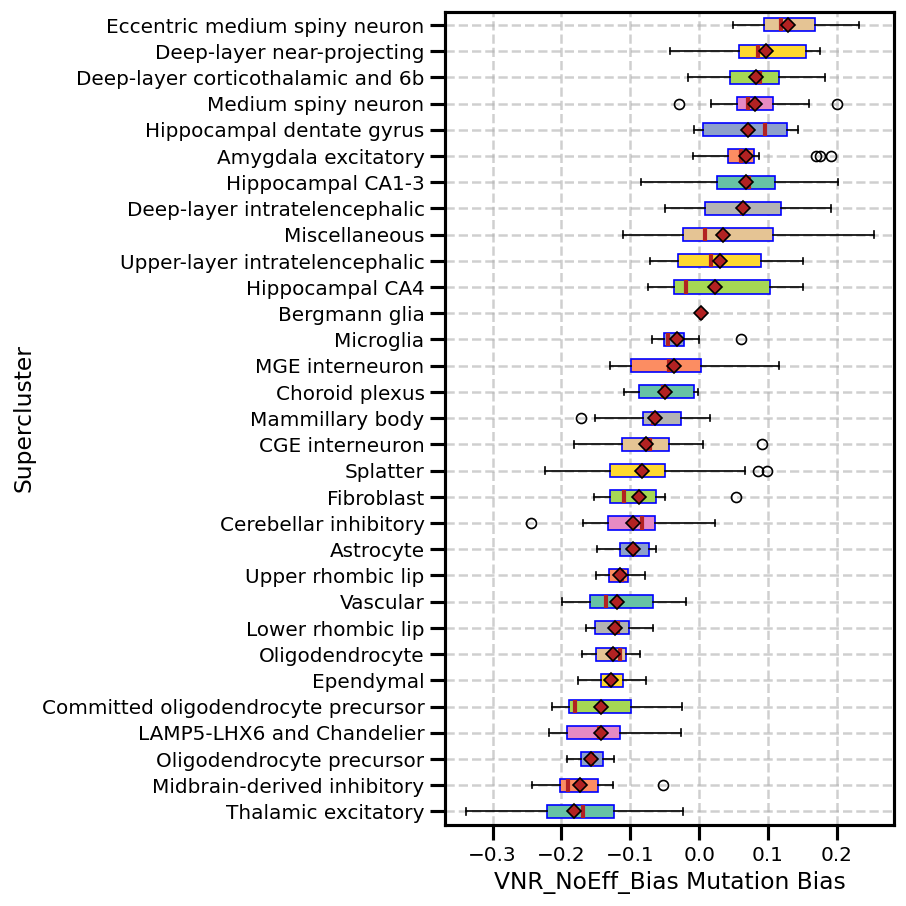

,Supercluster,Avg_supercluster_effect,P_value_gt,P_value_2sided,P_value_gt_adj
1,Eccentric medium spiny neuron,0.129107,5.475725e-08,1.095145e-07,0.000002
7,Deep-layer near-projecting,0.096854,6.321091e-06,1.264218e-05,0.000039
6,Deep-layer corticothalamic and 6b,0.082141,1.519157e-06,3.038315e-06,0.000016
3,Medium spiny neuron,0.080590,9.845153e-07,1.969031e-06,0.000015
10,Hippocampal dentate gyrus,0.070867,1.815844e-03,3.631688e-03,0.005629
5,Amygdala excitatory,0.067626,2.351476e-06,4.702952e-06,0.000018
2,Hippocampal CA1-3,0.067341,7.294445e-05,1.458889e-04,0.000323
4,Deep-layer intratelencephalic,0.063133,4.250982e-05,8.501964e-05,0.000220
0,Miscellaneous,0.034882,6.595119e-04,1.319024e-03,0.002556
9,Upper-layer intratelencephalic,0.030711,1.796936e-03,3.593872e-03,0.005629


In [86]:
VNR_NoEff_GW = Fil2Dict("{}/UKBB_VNR_NoEff_GW_{}.csv".format(GeneWeightDIR, topN))
VNR_NoEff_GW = {k: 1 for k in VNR_NoEff_GW.keys()}
VNR_NoEff_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT_clip5, VNR_NoEff_GW, Method = 1)
VNR_NoEff_Bias = AnnotateCTDat(VNR_NoEff_Bias, Anno)
VNR_NoEff_Bias.to_csv("{}/CTBias.VNR.NoEff.top61.csv".format(Bias_Save_Dict))
SuperClusterBias_BoxPlot(VNR_NoEff_Bias, "VNR_NoEff_Bias")
VNR_NoEff_Supercluster_Bias = compare_all_superclusters(VNR_NoEff_Bias)
VNR_NoEff_Supercluster_Bias

In [84]:
VNR_NoEff_GW

{401647: 1,
 5339: 1,
 79823: 1,
 81888: 1,
 1376: 1,
 8648: 1,
 3590: 1,
 259307: 1,
 3960: 1,
 10069: 1,
 129080: 1,
 55027: 1,
 5663: 1,
 6594: 1,
 6759: 1,
 79888: 1,
 91452: 1,
 83715: 1,
 3098: 1,
 170692: 1,
 114928: 1,
 654231: 1,
 79906: 1,
 7260: 1,
 55374: 1,
 22894: 1,
 283748: 1,
 6503: 1,
 84830: 1,
 161176: 1,
 55165: 1,
 55584: 1,
 3002: 1,
 79048: 1,
 79709: 1,
 51102: 1,
 129450: 1,
 8522: 1,
 4868: 1,
 1584: 1,
 57595: 1,
 79654: 1,
 23042: 1,
 731220: 1,
 54823: 1,
 79847: 1,
 114571: 1,
 23306: 1,
 64921: 1,
 83849: 1,
 51340: 1,
 129804: 1,
 55554: 1,
 10314: 1,
 90576: 1,
 2067: 1,
 284297: 1,
 54796: 1,
 1508: 1}

## BP

In [33]:
BP_GW = Fil2Dict("/home/jw3514/Work/CellType_Psy/dat/Archive/Bipolar.top61.gw.csv")
BP_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, BP_GW, Method = 1)
BP_Z2_Bias = AnnotateCTDat(BP_Z2_Bias, Anno)
#BP_Z2_Bias.to_csv("../dat/Bias/CTBias.BP.Z2.HCT.csv")
BP_Z2_Bias.to_csv("{}/HCT.BP.Z2.HCT.csv".format(Bias_Save_Dict))


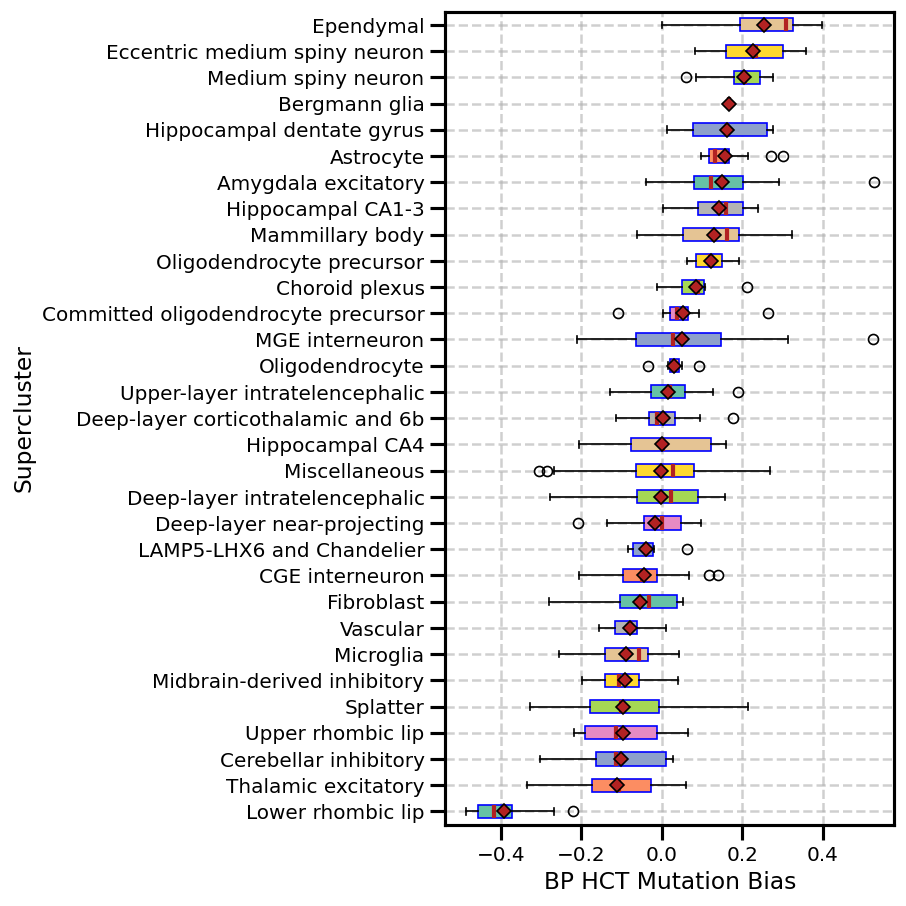

In [34]:
SuperClusterBias_BoxPlot(BP_Z2_Bias, "BP HCT")

## CNVs

In [35]:
genes_3q29 = [
    "BDH1",       # 3-hydroxybutyrate dehydrogenase 1
    "FBXO45",     # F-box protein 45
    "SENP5",      # SUMO specific peptidase 5
    "UBXN7",      # UBX domain protein 7
    "WDR53",      # WD repeat domain 53
    "CEP19",      # centrosomal protein 19
    "DLG1",       # discs large MAGUK scaffold protein 1
    "DYNLT2B",    # dynein light chain Tctex-type 2B
    "MELTF",      # melanotransferrin
    "NRROS",      # negative regulator of reactive oxygen species
    "NCBP2",      # nuclear cap binding protein subunit 2
    "PAK2",       # p21 (RAC1) activated kinase 2
    "PCYT1A",     # phosphate cytidylyltransferase 1A, choline
    "PIGX",       # phosphatidylinositol glycan anchor biosynthesis class X
    "PIGZ",       # phosphatidylinositol glycan anchor biosynthesis class Z
    "RNF168",     # ring finger protein 168
    "SMCO1",      # single-pass membrane protein with coiled-coil domains 1
    "SLC51A",     # solute carrier family 51 subunit alpha
    "TFRC",       # transferrin receptor
    "TM4SF19",    # transmembrane 4 L six family member 19
    "ZDHHC19"     # zinc finger DHHC-type palmitoyltransferase 19
]
genes_3q29_entrez = [int(GeneSymbol2Entrez[x]) for x in genes_3q29 if x in GeneSymbol2Entrez]
genes_3q29_GW = dict(zip(genes_3q29_entrez, [1]*len(genes_3q29_entrez)))
Dict2Fil(genes_3q29_GW, "/home/jw3514/Work/CellType_Psy/dat/GeneWeights/3q29.gw.csv")
genes_3q29_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, genes_3q29_GW, Method = 1)
genes_3q29_Bias = AnnotateCTDat(genes_3q29_Bias, Anno)
#genes_3q29_Bias.to_csv("../dat/Bias/CTBias.3q29.Z2.HCT.csv")
genes_3q29_Bias.to_csv("{}/HCT.3q29.Z2.HCT.csv".format(Bias_Save_Dict))

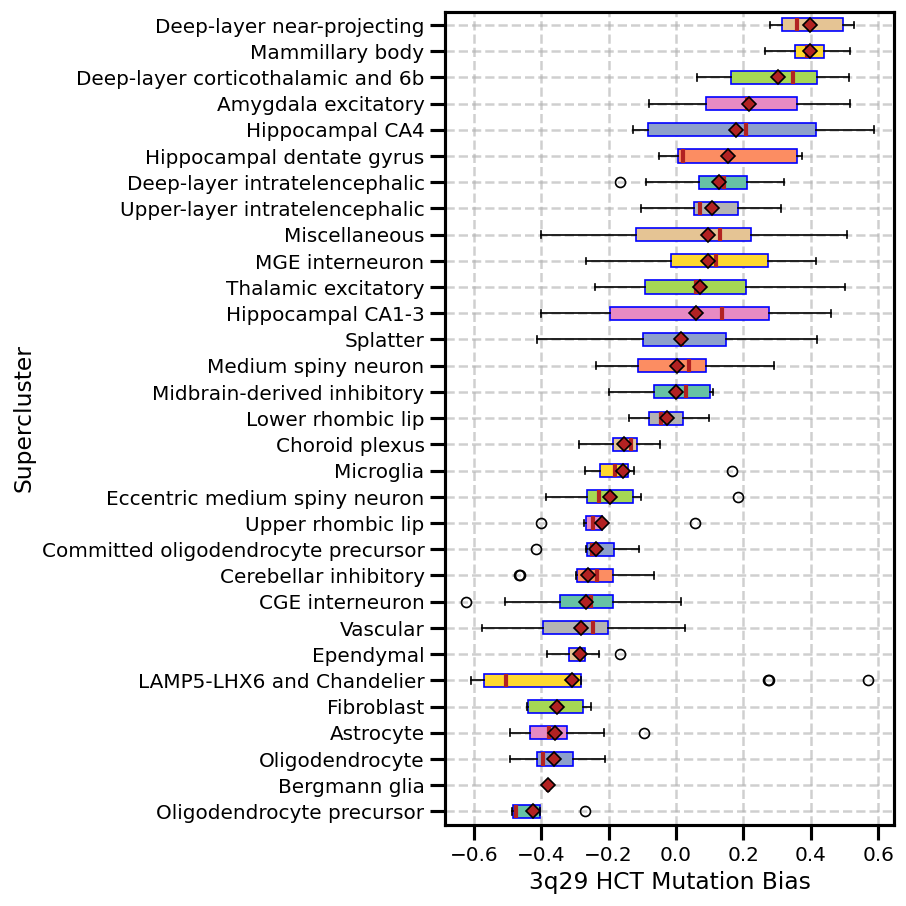

In [36]:
SuperClusterBias_BoxPlot(genes_3q29_Bias, "3q29 HCT")

In [37]:
X16p_df = pd.read_excel("~/Work/data/13073_2021_972_MOESM2_ESM.xlsx", sheet_name="16p11.2")
Gene16p11 = X16p_df[X16p_df["Type"]=="protein_coding"]["Gene_name"].values
Gene16p11 = [int(GeneSymbol2Entrez[x]) for x in Gene16p11 if x in GeneSymbol2Entrez.keys()]
print(len(Gene16p11))
X16pGW = dict(zip(Gene16p11, [1]*len(Gene16p11)))
Dict2Fil(X16pGW, "/home/jw3514/Work/CellType_Psy/dat/GeneWeights/16p11.gw.csv")

39


In [38]:
genes_16p11_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, X16pGW, Method = 1)
genes_16p11_Bias = AnnotateCTDat(genes_16p11_Bias, Anno)
#genes_16p11_Bias.to_csv("../dat/Bias/CTBias.16p11.Z2.HCT.csv")
genes_16p11_Bias.to_csv("{}/HCT.16p11.Z2.HCT.csv".format(Bias_Save_Dict))

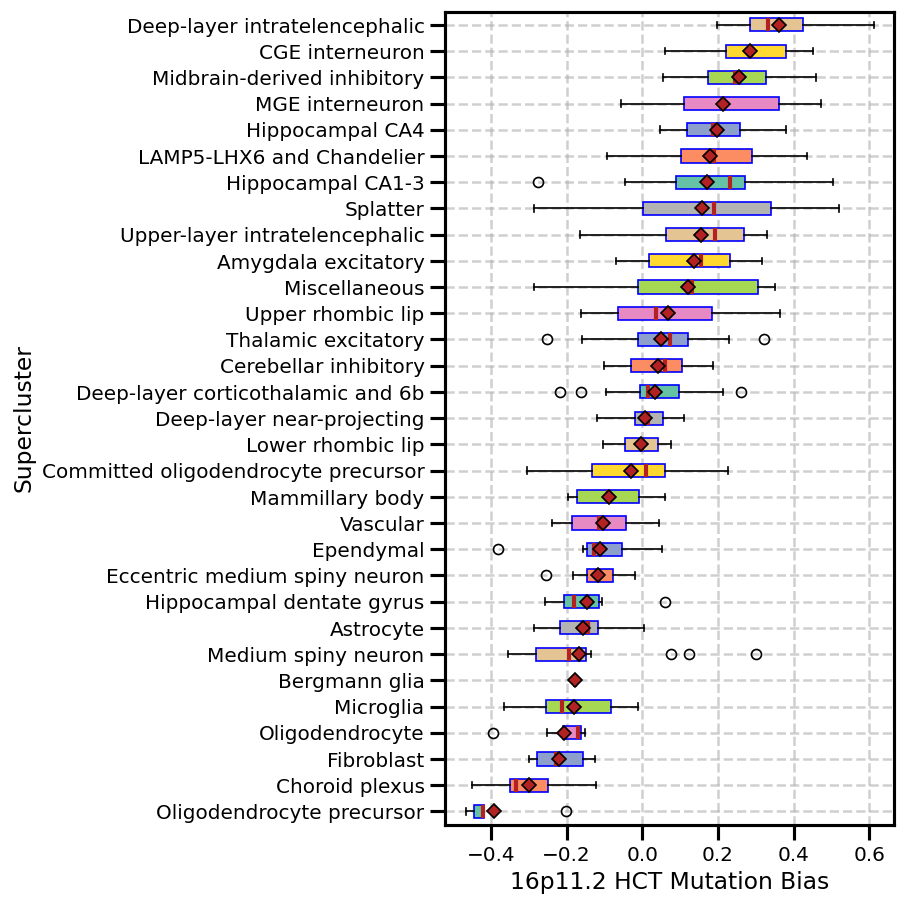

In [39]:
SuperClusterBias_BoxPlot(genes_16p11_Bias, "16p11.2 HCT")

In [40]:
print(len(genes_3q29_GW))
print(len(X16pGW))
print(len(X22q_GW))

21
39
46
